In [42]:
import numpy as np

import pandas as pd
import os
import datetime
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error  
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns


## Data

In [43]:
data=pd.read_excel('../data/virus_wea_ili.xlsx')
data.rename(columns={'viral_mean':'viral_A'}, inplace=True)
data

,date,viral_A,year,week,ILI,avgtem,mintem,maxtem,rain,wind,hum
0,2023-01-07,1.341490e+17,2023,1,52.50000,-0.011128,-4.991128,5.696541,1.296835,1.918045,58.908421
1,2023-01-14,2.065967e+16,2023,2,40.20000,4.776981,-0.636472,11.193124,12.017021,1.468012,74.538714
2,2023-01-21,1.778270e+17,2023,3,28.30000,-0.855655,-5.153720,3.821280,1.843891,2.198206,63.707292
3,2023-01-28,1.075471e+17,2023,4,25.60000,-4.274367,-9.306399,1.174702,1.338889,2.565476,56.108495
4,2023-02-04,2.560581e+16,2023,5,17.00000,0.547612,-4.836418,6.493284,0.347222,1.981024,54.461019
...,...,...,...,...,...,...,...,...,...,...,...
97,2024-11-16,1.724794e+13,2024,46,4.60000,13.977729,9.340353,20.255965,1.339098,1.248012,78.305015
98,2024-11-23,3.612775e+14,2024,47,4.80000,7.341532,2.130781,13.132990,1.165854,1.977761,62.125037
99,2024-11-30,1.138406e+14,2024,48,5.34375,5.964148,1.679142,10.656953,6.752632,2.577434,71.175847
100,2024-12-07,1.397429e+15,2024,49,6.84375,5.087001,0.566224,10.259587,0.542798,2.061856,62.667010


In [44]:
columns_to_augment=['viral_A', 'avgtem']
std_devs = data[columns_to_augment].std()
std_devs

viral_A    4.720816e+16
avgtem     9.233999e+00
dtype: float64

## Optimal Parameters

In [45]:
np.random.seed(42)

columns_to_augment = ['viral_A', 'avgtem']
col_std = data[columns_to_augment].std()  # pandas Series

def generate_augmented_data(original, noise_level, scale_factor, enforce_non_negative=False):
    noise = np.random.normal(0, scale=noise_level, size=len(original))
    scale = np.random.normal(1, scale=scale_factor) 
    augmented = original * scale + noise
    if enforce_non_negative:
        augmented = np.maximum(augmented, 0)
    return augmented

def variability_score(original, augmented):
    return abs(np.std(original) - np.std(augmented))

def get_search_ranges(col, std, n_grid=50):
    
    noise_range = np.linspace(0.01 * std, 0.05 * std, n_grid)
    scale_range = np.linspace(0.01, 0.05, n_grid)
    
    return noise_range, scale_range

records = []
optimal_params_data = {}

for col in columns_to_augment:
    std = col_std[col]
    enforce_non_negative = (col == 'viral_A')

    noise_range, scale_range = get_search_ranges(col, std, n_grid=50)

    best_score = np.inf
    best_params = None

    original = data[col].values

    for noise_level in noise_range:
        for scale_factor in scale_range:
            augmented = generate_augmented_data(original, noise_level, scale_factor, enforce_non_negative)

            mae = mean_absolute_error(original, augmented)
            variability = variability_score(original, augmented)
            score = 0.5 * mae + 0.5 * variability

            records.append({
                'col': col,
                'noise_level': float(noise_level),
                'scale_factor': float(scale_factor),
                'mae': float(mae),
                'variability': float(variability),
                'score': float(score),
            })

            if score < best_score:
                best_score = score
                best_params = {'noise_level': float(noise_level), 'scale_factor': float(scale_factor)}

    optimal_params_data[col] = best_params

df = pd.DataFrame(records)

print("Optimal Parameters:")
for col, params in optimal_params_data.items():
    print(f"{col}: Noise Level = {params['noise_level']:.2g}, Scale Factor = {params['scale_factor']:.2f}")

Optimal Parameters:
viral_A: Noise Level = 5.1e+14, Scale Factor = 0.04
avgtem: Noise Level = 0.092, Scale Factor = 0.01


In [46]:
# times new roman
plt.rcParams["font.family"] = "Times New Roman"

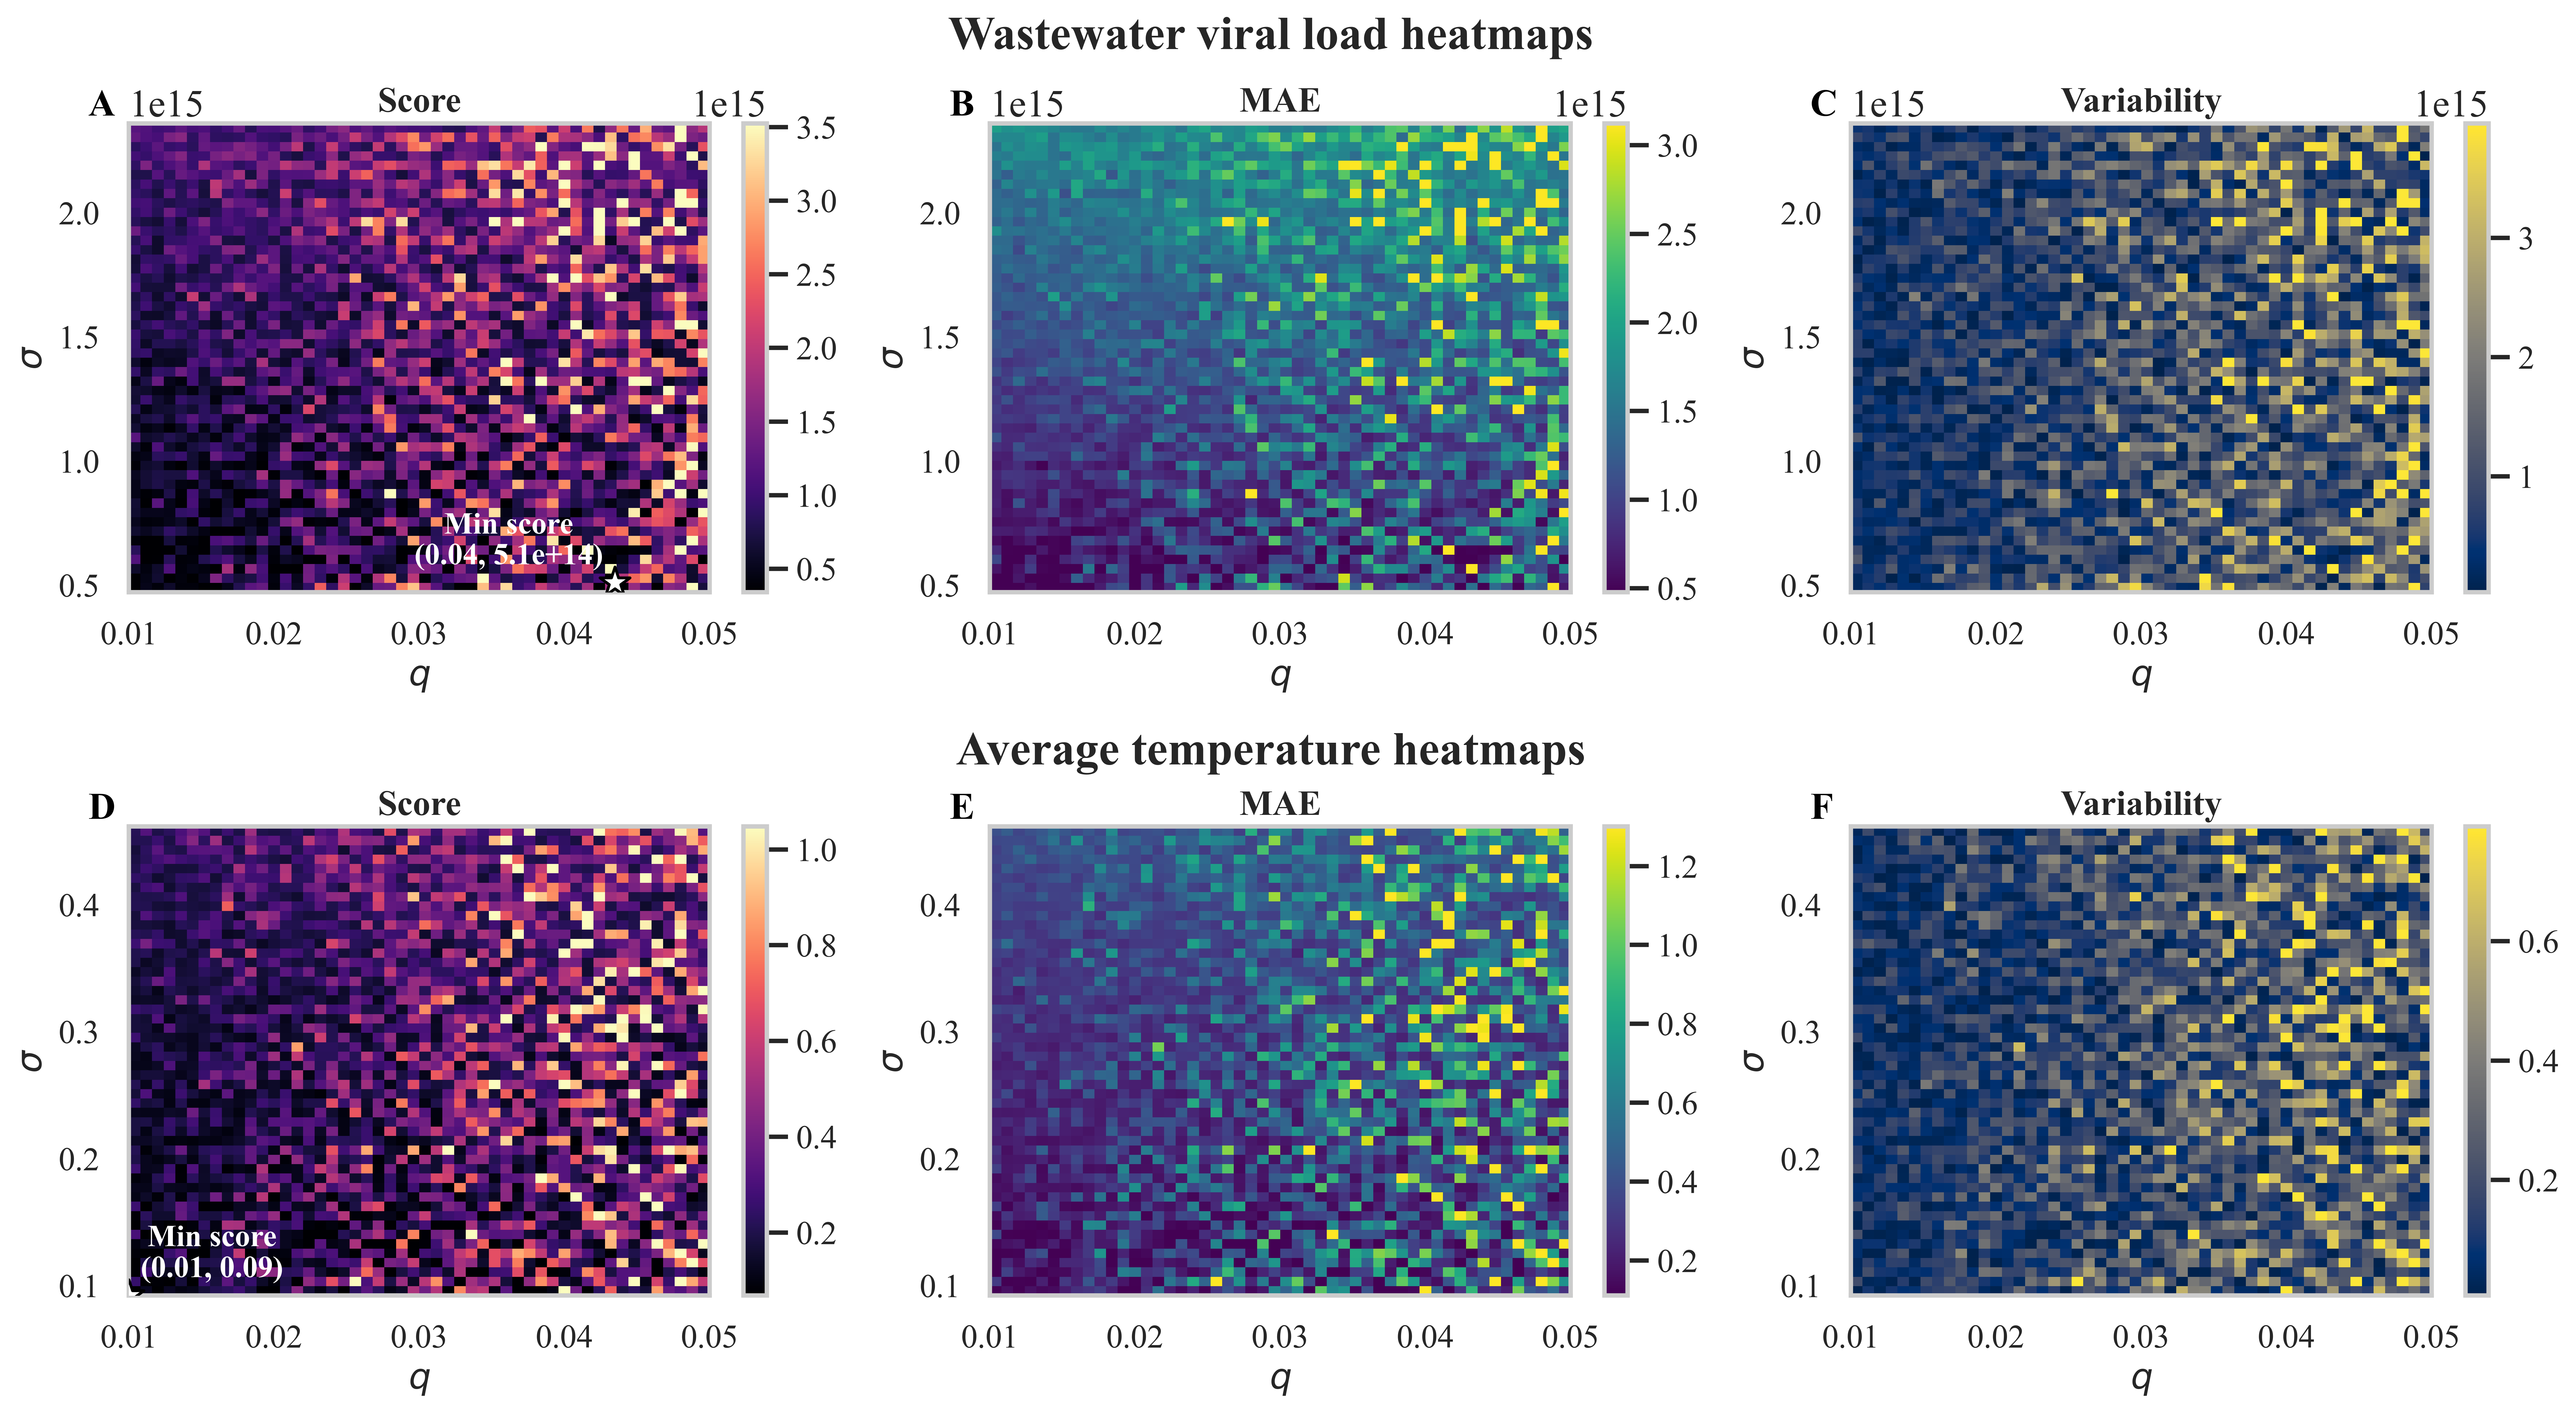

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_heatmap_ax(
    ax,
    df_col,
    value_col,
    title,
    cmap="viridis",
    robust=True,
    show_best=False,
    best_marker_kwargs=None,
    x_fmt=".2f",     
    y_fmt=".2f",     
    ann_xytext=(-8, 8),
    ann_ha="right"  
):
    pivot = df_col.pivot(index="noise_level", columns="scale_factor", values=value_col)
    pivot = pivot.sort_index(axis=0).sort_index(axis=1)
    vals = pivot.values.astype(float)

    if robust:
        vmin, vmax = np.nanpercentile(vals, [2, 98])
        if np.isclose(vmin, vmax):
            vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    else:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)

    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

    im = ax.imshow(
        vals,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        norm=norm,
        extent=[pivot.columns.min(), pivot.columns.max(),
                pivot.index.min(), pivot.index.max()],
        interpolation="nearest"
    )
    ax.grid(False)

    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.set_ylabel(r'$\sigma$', fontsize=15)
    ax.set_xlabel(r'$q$', fontsize=15)
    ax.set_title(title)

    if show_best:
        best_row = df_col.loc[df_col["score"].idxmin()]
        bx, by = float(best_row["scale_factor"]), float(best_row["noise_level"])

        if best_marker_kwargs is None:
            best_marker_kwargs = dict(
                s=180, marker="*", c="white",
                edgecolors="black", linewidths=1.2, zorder=3
            )

        ax.scatter([bx], [by], **best_marker_kwargs)

        label = f"Min score\n({bx:{x_fmt}}, {by:{y_fmt}})"

        ax.annotate(
            label,
            (bx, by),
            xytext=ann_xytext,
            textcoords="offset points",
            color="white",
            fontsize=13,
            ha=ann_ha,
            va="bottom",
            multialignment="center",
            fontweight="bold",
        )

    return im


row_cols = ["viral_A", "avgtem"]
metrics = [
    ("score", "magma", True,  True),
    ("mae", "viridis", True,  False),
    ("variability", "cividis", True, False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=False, dpi=600)
fig.subplots_adjust(wspace=0.35, hspace=0.5)

panel_labels = list("ABCDEF")
k = 0

metric_title = {"score": "Score", "mae": "MAE", "variability": "Variability"}
col_title = {"viral_A": "Viral load", "avgtem": "Average temperature"}

for r, col in enumerate(row_cols):
    d = df[df["col"] == col].copy()
    y_fmt = ".2g" if col == "viral_A" else ".2f"

    for c, (value_col, cmap, robust, show_best) in enumerate(metrics):
        ax = axes[r, c]

        title = f"{metric_title.get(value_col, value_col)}"
    
        panel = panel_labels[k]

        if panel == "A":
            ann_xytext = (-5, 5) 
            ann_ha = "right"
        elif panel == "D":
            ann_xytext = (5, 5)  
            ann_ha = "left"

        im = plot_heatmap_ax(
            ax=ax,
            df_col=d,
            value_col=value_col,
            title=title,
            cmap=cmap,
            robust=robust,
            show_best=show_best,
            x_fmt=".2f",      
            y_fmt=y_fmt,     
            ann_xytext=ann_xytext,  
            ann_ha=ann_ha      
        )
        ax.set_title(title, pad=5, fontsize=15, fontweight="bold")

        ax.text(
            -0.07, 1.07, panel_labels[k],         
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=16, fontweight="bold",
            color="black",
            clip_on=False                  
        )
        k += 1

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.2) 
        cbar = fig.colorbar(im, cax=cax)
        cbar.ax.tick_params(labelsize=14)   


row1_title = "Wastewater viral load heatmaps"  
row2_title = "Average temperature heatmaps" 

fig.text(0.5, 0.95, row1_title, ha="center", va="top", fontsize=20, fontweight="bold")
fig.text(0.5, 0.48, row2_title,ha="center", va="top", fontsize=20, fontweight="bold")

plt.show()

## Augmentation

In [48]:
data = pd.read_excel('../data/virus_wea_ili.xlsx')
data.rename(columns={'viral_mean':'viral_A'}, inplace=True)

def generate_augmented_data(original, noise_level, scale_factor, col_name, num_augmentations=10):
    augmented = []
    for _ in range(num_augmentations):
        noise = np.random.normal(0, noise_level, size=len(original))
        scale = np.random.normal(1, scale=scale_factor)
        augmented_data = original * scale + noise

        
        if col_name in ['viral_A']:
            augmented_data = np.maximum(augmented_data, 0)  

        augmented.append(augmented_data)
    return np.vstack(augmented)

columns_to_augment = ['viral_A', 'avgtem']
num_augmentations = 1000

augmented_columns = {}

for i in range(num_augmentations):
    for col in columns_to_augment:
        params = optimal_params_data[col]
        augmented_col = generate_augmented_data(
            original=data[col],
            noise_level=params['noise_level'],
            scale_factor=params['scale_factor'],
            col_name=col,
            num_augmentations=1
        )[0]  # shape: (n_rows,)
        augmented_columns[f"{col}_{i+1}"] = augmented_col

augmented_df = pd.DataFrame(augmented_columns)

augmented_df.insert(0, 'week', data['week'].values)
augmented_df.insert(0, 'year', data['year'].values)


In [49]:
data=data[['year', 'week', 'viral_A', 'ILI', 'avgtem']].copy()

In [50]:
data_augmented_final=pd.merge(data, augmented_df, on=['year', 'week'], how='left')
data_augmented_final

,year,week,viral_A,ILI,avgtem,viral_A_1,avgtem_1,viral_A_2,avgtem_2,viral_A_3,...,viral_A_996,avgtem_996,viral_A_997,avgtem_997,viral_A_998,avgtem_998,viral_A_999,avgtem_999,viral_A_1000,avgtem_1000
0,2023,1,1.341490e+17,52.50000,-0.011128,1.289970e+17,0.018055,1.334752e+17,0.068688,1.319687e+17,...,1.395695e+17,0.011185,1.342778e+17,-0.103271,1.363779e+17,-0.080320,1.419358e+17,0.020197,1.318255e+17,0.171105
1,2023,2,2.065967e+16,40.20000,4.776981,1.978342e+16,4.878928,2.056190e+16,4.740550,2.024041e+16,...,2.162341e+16,4.874037,2.133406e+16,4.852087,2.101048e+16,4.981179,2.201592e+16,4.832893,2.057340e+16,4.752970
2,2023,3,1.778270e+17,28.30000,-0.855655,1.701063e+17,-0.804472,1.770363e+17,-0.808186,1.744645e+17,...,1.847905e+17,-0.904280,1.776570e+17,-0.792992,1.813270e+17,-0.743931,1.881883e+17,-1.035401,1.744144e+17,-1.181615
3,2023,4,1.075471e+17,25.60000,-4.274367,1.030406e+17,-4.243264,1.074548e+17,-4.224219,1.054457e+17,...,1.114472e+17,-4.373462,1.075594e+17,-4.162727,1.099329e+17,-4.387666,1.148986e+17,-4.196191,1.054124e+17,-4.222171
4,2023,5,2.560581e+16,17.00000,0.547612,2.545740e+16,0.559413,2.565480e+16,0.513180,2.543919e+16,...,2.685326e+16,0.381340,2.573252e+16,0.390227,2.549479e+16,0.507812,2.605956e+16,0.557343,2.516919e+16,0.526035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,2024,46,1.724794e+13,4.60000,13.977729,0.000000e+00,14.056001,0.000000e+00,14.188078,0.000000e+00,...,0.000000e+00,13.955253,0.000000e+00,13.897763,6.009793e+14,14.341996,2.019178e+14,13.997531,1.095128e+12,13.986472
98,2024,47,3.612775e+14,4.80000,7.341532,8.028703e+14,7.363826,1.281617e+15,7.494354,2.005531e+14,...,8.964591e+14,7.405196,4.262123e+14,7.105200,2.127846e+14,7.609332,6.519307e+14,7.195985,0.000000e+00,7.188446
99,2024,48,1.138406e+14,5.34375,5.964148,8.445622e+13,5.889108,0.000000e+00,5.974134,9.985663e+14,...,0.000000e+00,6.036158,7.259308e+14,5.881824,0.000000e+00,6.069274,0.000000e+00,6.030194,0.000000e+00,6.035153
100,2024,49,1.397429e+15,6.84375,5.087001,1.800932e+15,5.084741,2.188353e+15,4.944361,1.693769e+15,...,1.790970e+15,5.130559,1.465236e+15,4.802642,6.883493e+14,5.194628,1.783962e+15,5.079316,7.987529e+14,5.044561


In [51]:
data_augmented_final.to_excel('../Data/data_augmented_1000.xlsx', index=False)

## LSTM


In [52]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch import nn

In [53]:
torch.cuda.is_available()

True

In [54]:
data=pd.read_excel('../Data/data_augmented_1000.xlsx')
data

,year,week,viral_A,ILI,avgtem,viral_A_1,avgtem_1,viral_A_2,avgtem_2,viral_A_3,...,viral_A_996,avgtem_996,viral_A_997,avgtem_997,viral_A_998,avgtem_998,viral_A_999,avgtem_999,viral_A_1000,avgtem_1000
0,2023,1,1.341490e+17,52.50000,-0.011128,1.289970e+17,0.018055,1.334752e+17,0.068688,1.319687e+17,...,1.395695e+17,0.011185,1.342778e+17,-0.103271,1.363779e+17,-0.080320,1.419358e+17,0.020197,1.318255e+17,0.171105
1,2023,2,2.065967e+16,40.20000,4.776981,1.978342e+16,4.878928,2.056190e+16,4.740550,2.024041e+16,...,2.162341e+16,4.874037,2.133406e+16,4.852087,2.101048e+16,4.981179,2.201592e+16,4.832893,2.057340e+16,4.752970
2,2023,3,1.778270e+17,28.30000,-0.855655,1.701063e+17,-0.804472,1.770363e+17,-0.808186,1.744645e+17,...,1.847905e+17,-0.904280,1.776570e+17,-0.792992,1.813270e+17,-0.743931,1.881883e+17,-1.035401,1.744144e+17,-1.181615
3,2023,4,1.075471e+17,25.60000,-4.274367,1.030406e+17,-4.243264,1.074548e+17,-4.224219,1.054457e+17,...,1.114472e+17,-4.373462,1.075594e+17,-4.162727,1.099329e+17,-4.387666,1.148986e+17,-4.196191,1.054124e+17,-4.222171
4,2023,5,2.560581e+16,17.00000,0.547612,2.545740e+16,0.559413,2.565480e+16,0.513180,2.543919e+16,...,2.685326e+16,0.381340,2.573252e+16,0.390227,2.549479e+16,0.507812,2.605956e+16,0.557343,2.516919e+16,0.526035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,2024,46,1.724794e+13,4.60000,13.977729,0.000000e+00,14.056001,0.000000e+00,14.188078,0.000000e+00,...,0.000000e+00,13.955253,0.000000e+00,13.897763,6.009793e+14,14.341996,2.019178e+14,13.997531,1.095128e+12,13.986472
98,2024,47,3.612775e+14,4.80000,7.341532,8.028703e+14,7.363826,1.281617e+15,7.494354,2.005531e+14,...,8.964591e+14,7.405196,4.262123e+14,7.105200,2.127846e+14,7.609332,6.519307e+14,7.195985,0.000000e+00,7.188446
99,2024,48,1.138406e+14,5.34375,5.964148,8.445622e+13,5.889108,0.000000e+00,5.974134,9.985663e+14,...,0.000000e+00,6.036158,7.259308e+14,5.881824,0.000000e+00,6.069274,0.000000e+00,6.030194,0.000000e+00,6.035153
100,2024,49,1.397429e+15,6.84375,5.087001,1.800932e+15,5.084741,2.188353e+15,4.944361,1.693769e+15,...,1.790970e+15,5.130559,1.465236e+15,4.802642,6.883493e+14,5.194628,1.783962e+15,5.079316,7.987529e+14,5.044561


In [55]:
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

In [56]:
class EarlyStopping: 
    def __init__(self, model, patience=50, delta=0.0, mode='min', verbose=True, save_path='C:/Users/user/Desktop/23-24_model_water/best_model.pth'): # 초기화 메서드

        self.early_stop = False 
        self.patience = patience
        self.verbose = verbose
        self.counter = 0 
        self.mode = mode 
        self.delta = delta 
        self.model = model 
        self.save_path = save_path 

        os.makedirs(os.path.dirname(self.save_path), exist_ok=True)

        self.best_score = np.Inf if mode == 'min' else -np.Inf 

    def __call__(self, score):

        if isinstance(score, torch.Tensor):
            score = score.cpu().numpy()

        if self.mode == 'min':
            if score < (self.best_score - self.delta):
                self.counter = 0
                self.best_score = score
               
                torch.save(self.model.state_dict(), self.save_path)
            else:
                self.counter += 1

        elif self.mode == 'max':
            if score > (self.best_score + self.delta):
                self.counter = 0
                self.best_score = score

                torch.save(self.model.state_dict(), self.save_path)
            else:
                self.counter += 1


        if self.counter >= self.patience:
            self.early_stop = True


In [57]:
import torch
import torch.nn as nn

class Net(nn.Module):  
    def __init__(self, input_dim, hidden_dim, seq_len, output_dim, layers, dropout_prob):
        super(Net, self).__init__() 

        self.hidden_dim = hidden_dim
        self.seq_len = seq_len
        self.output_dim = output_dim
        self.layers = layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=layers, batch_first=True, dropout=dropout_prob)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim, bias=True)
        self.relu = nn.ReLU()


    def reset_hidden_state(self, batch_size, device):

        return (
            torch.zeros(self.layers, batch_size, self.hidden_dim).to(device),
            torch.zeros(self.layers, batch_size, self.hidden_dim).to(device)
        )

    def forward(self, x):

        x, _status = self.lstm(x) 
        x = self.dropout(x[:, -1])  
        x = self.fc(x)  
        x = self.relu(x)  
        return x


In [58]:
data_dim=2
output_dim=1 
window_size=52

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device}")

Using cuda


In [59]:
import torch
import torch.nn as nn
import numpy as np

def train_model(model, train_df, val_df, num_epochs, lr, verbose=50, patience=50):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device) 

    criterion = nn.MSELoss().to(device)  
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  
    
    scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=lr * 0.1,max_lr=lr,step_size_up=20,   mode='triangular2',cycle_momentum=False )

    train_hist = np.zeros(num_epochs)  
    val_hist = np.zeros(num_epochs)  

    es = EarlyStopping(model=model, patience=patience, delta=0, mode='min', verbose=True)

    train_epoch = 0 
    for epoch in range(num_epochs):
        avg_cost = 0  
        total_batch = len(train_df) 

        model.train() 
        for samples in enumerate(train_df):
            x_train, y_train = samples  
            x_train, y_train = x_train.to(device), y_train.to(device) 

            outputs = model(x_train)  
            loss = criterion(outputs, y_train) 
            
            optimizer.zero_grad() 
            loss.backward()  
            optimizer.step()  
            
            avg_cost += loss / total_batch  

        train_hist[epoch] = avg_cost.item()  

        model.eval()  
        with torch.no_grad(): 
            val_loss = 0
            for batch_idx, samples in enumerate(val_df):
                x_val, y_val = samples
                x_val, y_val = x_val.to(device), y_val.to(device)  

                val_outputs = model(x_val) 
                val_loss += criterion(val_outputs, y_val) / len(val_df)  

            val_hist[epoch] = val_loss.item() 

        scheduler.step(val_loss.item()) 
        current_lr = optimizer.param_groups[0]['lr']

        if epoch % verbose == 0: 
           print(f'Epoch: {epoch:04d}, Train Loss: {avg_cost:.6f}, Validation Loss: {val_loss:.6f}', f'Learning Rate: {current_lr:.6f}')

        es(val_loss)
        if es.early_stop:
            train_epoch = epoch
            print("Early stopping")
            break  

    return model.eval(), train_hist, val_hist, train_epoch


In [60]:
def make_dataset(dis, label, window_size):
    feature_list = []
    label_list = []
    
    for i in range(len(dis) - window_size):
        feature = dis.iloc[i:i+window_size].values.reshape(window_size, -1)  
        label_value = label.iloc[i+window_size]  
        
        feature_list.append(feature)
        label_list.append(label_value)

    return np.array(feature_list), np.array(label_list).reshape(-1, 1)


In [61]:
train = data.iloc[:-4] 
test = data.iloc[-4:]   

In [62]:
from sklearn.preprocessing import MinMaxScaler

def calculate_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    return IQR

In [63]:
best_model=torch.load('../Model/lstm_model_all.pth', weights_only=False)

In [64]:
data['viral_A_1001']=data['viral_A']
data['avgtem_1001']=data['avgtem']

In [65]:
from sklearn.preprocessing import MinMaxScaler

train_predictions = []
test_predictions = []
col_names = []

scaling_features = ['viral_A', 'avgtem','ILI']
train_set_for_scaler = data[:len(train)][scaling_features].copy()

scaler = MinMaxScaler()
scaler.fit(train_set_for_scaler)

A_min = train_set_for_scaler['ILI'].min()
A_max = train_set_for_scaler['ILI'].max()

original_train_actual = data.loc[window_size:len(train)-1, 'ILI'].reset_index(drop=True).values
original_test_actual = data.loc[test.index[0]:test.index[-1], 'ILI'].reset_index(drop=True).values

train_predictions.append(original_train_actual)
test_predictions.append(original_test_actual)
col_names.append('actual')

for i in range(1, 1002):
    viral_col = f'viral_A_{i}'
    avg_col = f'avgtem_{i}'

    train_raw = pd.DataFrame({
        'viral_A': data.loc[:len(train)-1, viral_col].values,
        'avgtem': data.loc[:len(train)-1, avg_col].values,
        'ILI': data.loc[:len(train)-1, 'ILI'].values

    })

    test_raw = pd.DataFrame({
        'viral_A': data.loc[test.index[0] - window_size:test.index[-1], viral_col].values,
        'avgtem': data.loc[test.index[0] - window_size:test.index[-1], avg_col].values,
        'ILI': data.loc[test.index[0] - window_size:test.index[-1], 'ILI'].values
    })
    test_raw.index = range(len(test_raw))  

    train_scaled = pd.DataFrame(scaler.transform(train_raw), columns=scaling_features, index=train_raw.index)
    test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=scaling_features, index=test_raw.index)

    train_scaled = train_scaled.rename(columns={'viral_A': viral_col, 'avgtem': avg_col})
    test_scaled = test_scaled.rename(columns={'viral_A': viral_col, 'avgtem': avg_col})

    train_feature = train_scaled[[viral_col, avg_col]]
    train_label = train_scaled[['ILI']]
    test_feature = test_scaled[[viral_col, avg_col]]
    test_label = test_scaled[['ILI']]

    trainX_np, trainY_np = make_dataset(train_feature, train_label, window_size)
    testX_np, testY_np = make_dataset(test_feature, test_label, window_size)

    trainX_tensor = torch.FloatTensor(trainX_np).to(device)
    testX_tensor = torch.FloatTensor(testX_np).to(device)

    best_model.eval()
    with torch.no_grad():
        train_preds = [torch.flatten(best_model(torch.unsqueeze(x, 0))).item() for x in trainX_tensor]
        test_preds = [torch.flatten(best_model(torch.unsqueeze(x, 0))).item() for x in testX_tensor]

    train_preds_unscaled = np.array(train_preds) * (A_max - A_min) + A_min
    test_preds_unscaled = np.array(test_preds) * (A_max - A_min) + A_min

    train_predictions.append(train_preds_unscaled)
    test_predictions.append(test_preds_unscaled)
    col_names.append(f'{viral_col}__{avg_col}')

train_result_df = pd.DataFrame(np.column_stack(train_predictions), columns=col_names)
test_result_df = pd.DataFrame(np.column_stack(test_predictions), columns=col_names)


In [66]:
import re
import numpy as np

def compute_ci(data_array, lower=2.5, upper=97.5):
    median   = np.percentile(data_array, 50,  axis=1)
    ci_lower = np.percentile(data_array, lower, axis=1)
    ci_upper = np.percentile(data_array, upper, axis=1)
    return median, ci_lower, ci_upper

pair_pattern = re.compile(r'^viral_A_(\d+)__avgtem_(\d+)$')

def select_pair_cols(columns):
    selected = []
    for c in columns:
        m = pair_pattern.match(c)
        if m:
            i1, i2 = int(m.group(1)), int(m.group(2))
            if i1 == i2 and i1 != 1001:
                selected.append(c)
    return selected


ci_columns_train = select_pair_cols(train_result_df.columns)
ci_columns_test  = select_pair_cols(test_result_df.columns)

# train
train_array = train_result_df[ci_columns_train].values  # shape: (T_train, N_members)
train_mean, train_ci_lower, train_ci_upper = compute_ci(train_array)

# test
test_array = test_result_df[ci_columns_test].values    # shape: (T_test, N_members)
test_mean, test_ci_lower, test_ci_upper = compute_ci(test_array)

train_result_df["mean"] = train_mean
train_result_df["ci_lower"] = train_ci_lower
train_result_df["ci_upper"] = train_ci_upper

test_result_df["mean"] = test_mean
test_result_df["ci_lower"] = test_ci_lower
test_result_df["ci_upper"] = test_ci_upper


In [67]:
date=data.loc[52:][['year', 'week']].reset_index(drop=True)
merged=pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)
final_result = pd.concat([date, merged], axis=1)
final_result.to_excel('../data/predictions_1000_augmentations.xlsx', index=False)

In [68]:
data_augmented_merged = pd.read_excel('../data/data_augmented_1000.xlsx')

viral_cols_100 = [f'viral_A_{i+1}' for i in range(1000)]
viral_all_cols = ['viral_A'] + viral_cols_100

df_viral_long = data_augmented_merged[viral_all_cols].reset_index().melt(
    id_vars='index', var_name='Series', value_name='Value'
)
df_viral_long.rename(columns={'index': 'Week'}, inplace=True)

avg_cols_100 = [f'avgtem_{i+1}' for i in range(1000)]
avg_all_cols = ['avgtem'] + avg_cols_100

df_avg_long = data_augmented_merged[avg_all_cols].reset_index().melt(
    id_vars='index', var_name='Series', value_name='Value'
)
df_avg_long.rename(columns={'index': 'Week'}, inplace=True)

In [69]:
data=pd.read_excel('../Data/virus_wea_ili.xlsx')

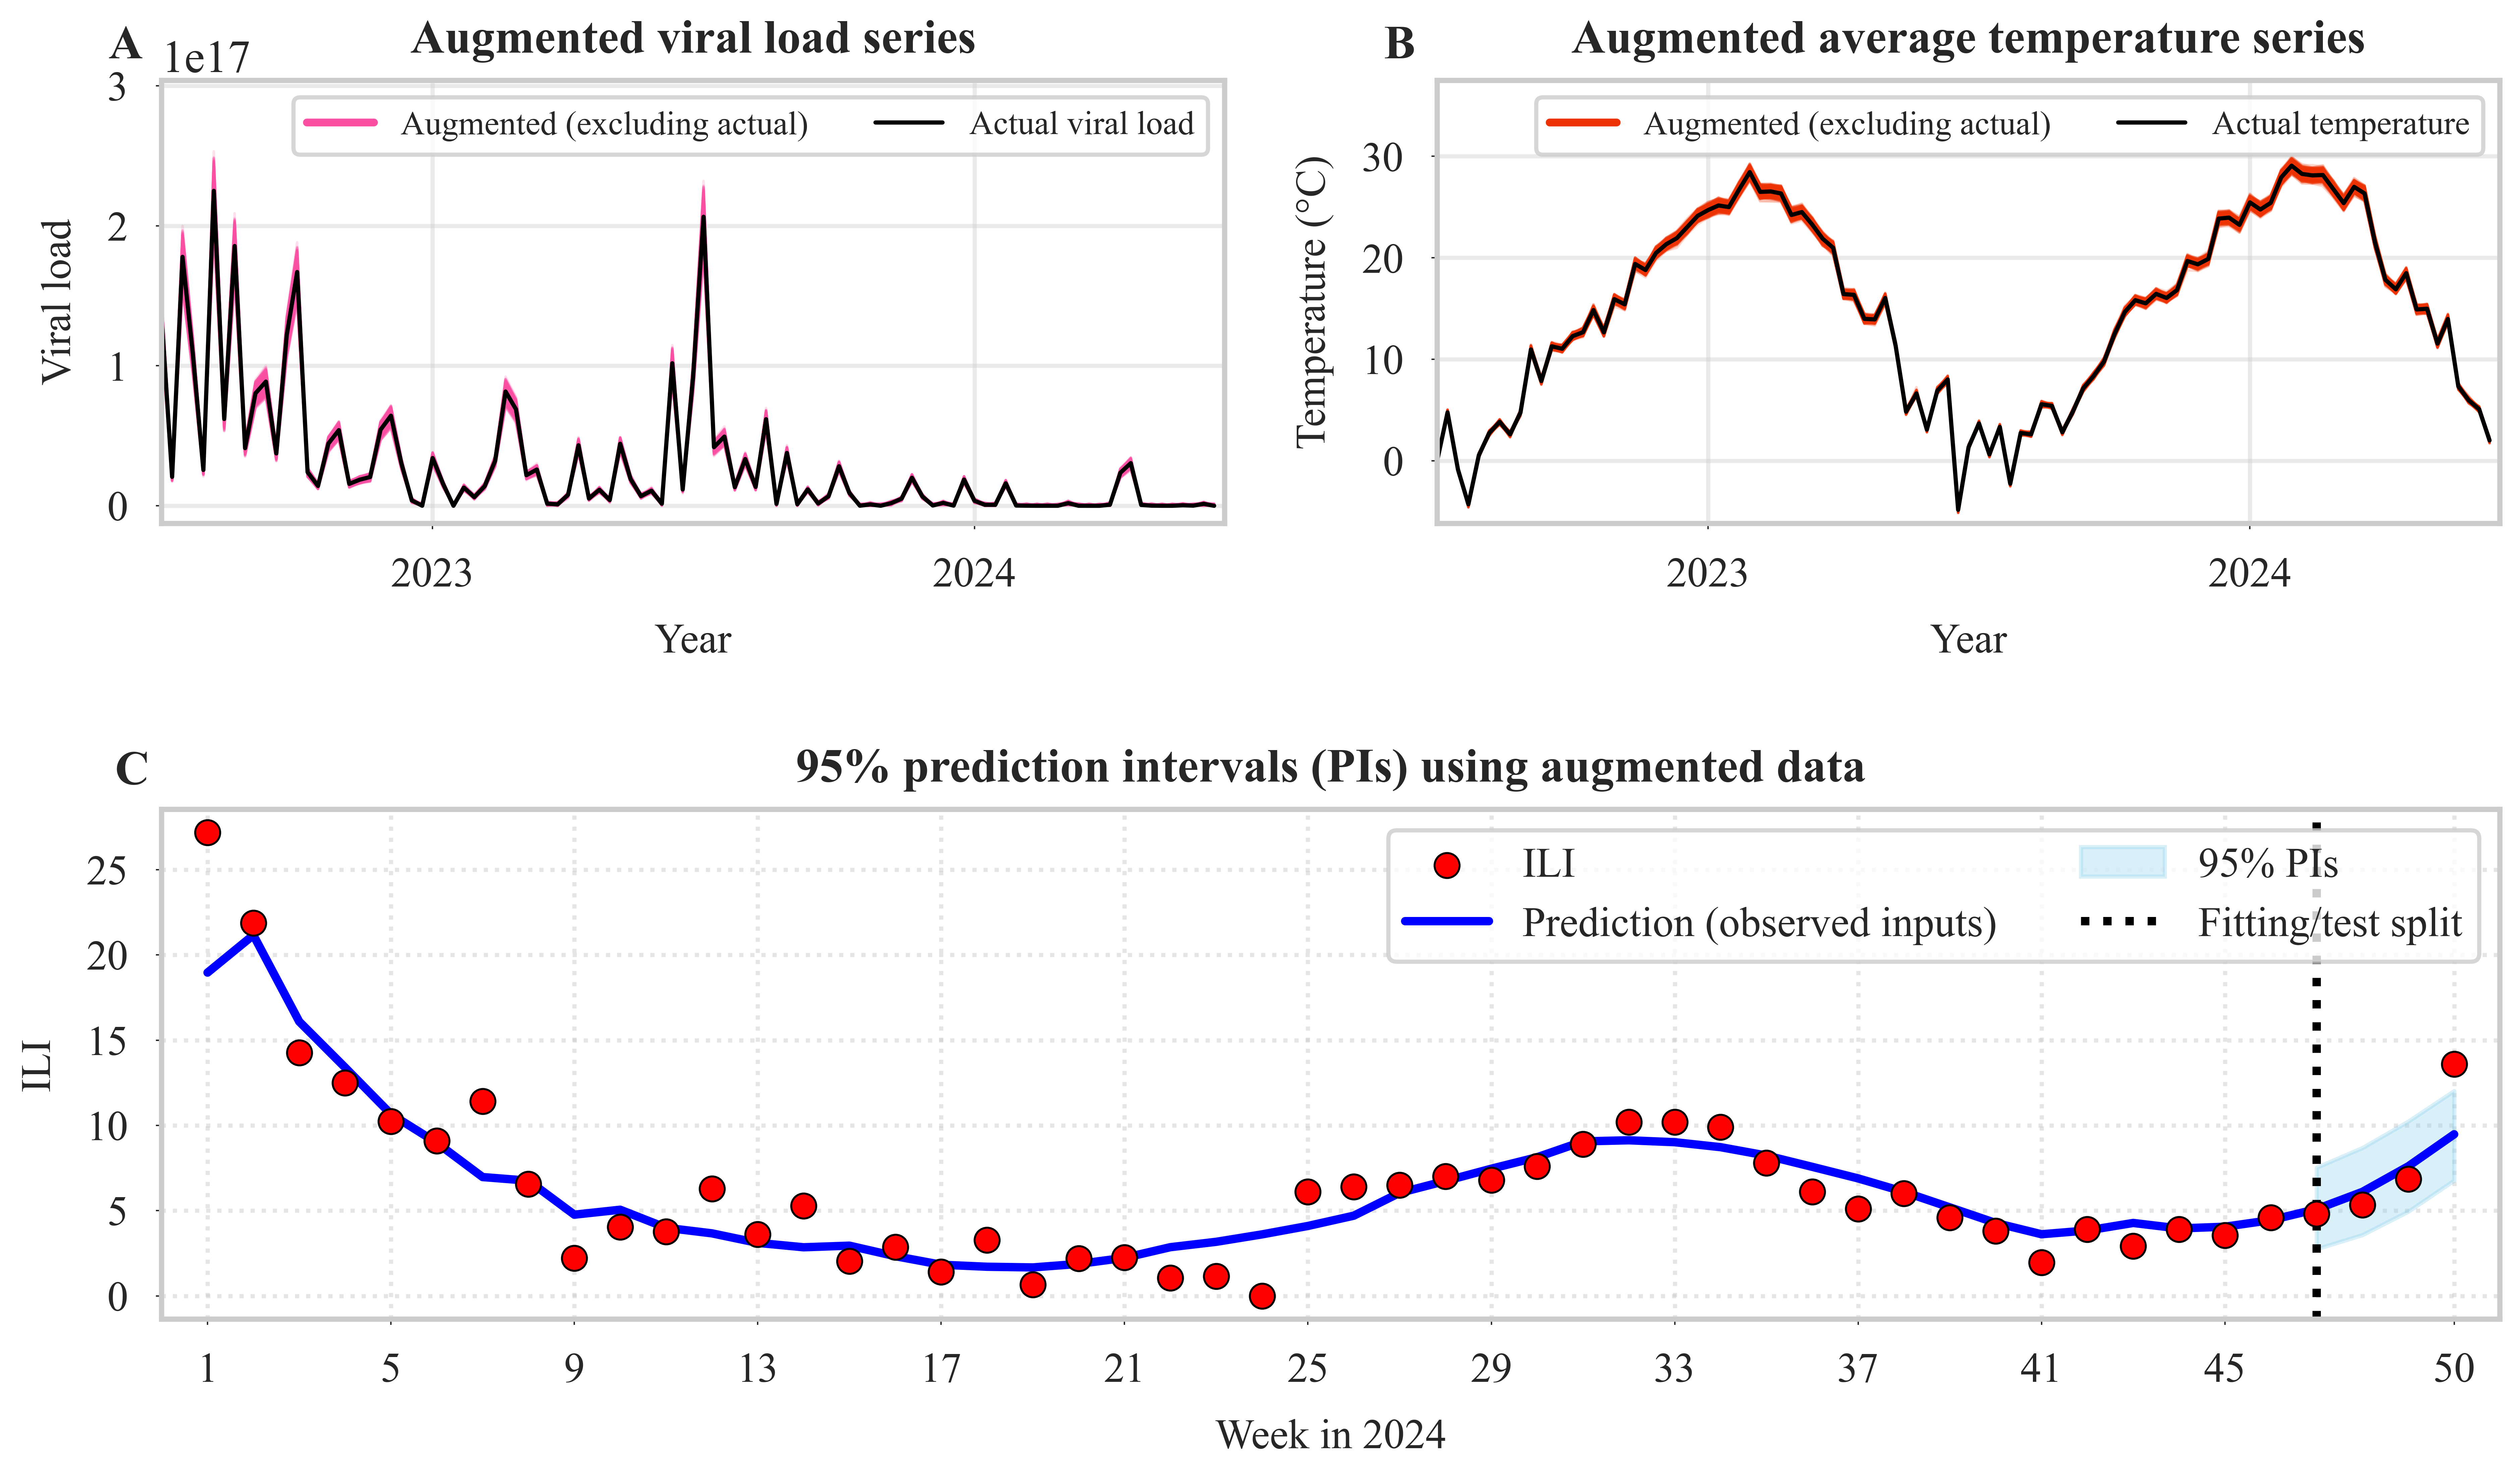

In [70]:
from matplotlib.lines import Line2D
# times new roman
plt.rcParams['font.family'] = 'Times New Roman'

# ====================
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.6, wspace=0.2)

ax_viral = fig.add_subplot(gs[0, 0]) 
ax_temp  = fig.add_subplot(gs[0, 1]) 
ax_pred  = fig.add_subplot(gs[1, :])  


# ====================
aug_color = "#f950a4"  
aug_color2 = "#ed3204"  
aug_alpha = 0.18
aug_lw    = 0.9

act_color = "black"    
act_alpha = 1.0
act_lw    = 1.5

# ====================
# (A) Viral plot (top-left) 
for i, col in enumerate(viral_cols_100):
    temp_df = df_viral_long[df_viral_long['Series'] == col]
    sns.lineplot(
        ax=ax_viral, data=temp_df, x='Week', y='Value',
        color=aug_color, linewidth=aug_lw, alpha=aug_alpha,
        legend=False,
        label=("Augmented (excluding actual)" if i == 0 else None)
    )

highlight_df_viral = df_viral_long[df_viral_long['Series'] == 'viral_A']
sns.lineplot(
    ax=ax_viral, data=highlight_df_viral, x='Week', y='Value',
    color=act_color, linewidth=act_lw, alpha=act_alpha,
    label='Actual viral load'
)

ax_viral.set_title("Augmented viral load series", fontsize=17, pad=10, fontweight='bold')
ax_viral.set_ylabel("Viral load", fontsize=15, labelpad=10)
ax_viral.set_xlabel("Year", fontsize=15, labelpad=10)
ax_viral.grid(True, alpha=0.4)
ax_viral.set_xlim(0, 102)
ax_viral.set_xticks(data.index[26::52], data['year'][26::52])

vmin = df_viral_long["Value"].min()
vmax = df_viral_long["Value"].max()
vrng = vmax - vmin

pad_low  = 0.05 * vrng 

ax_viral.set_ylim(vmin - pad_low, 1.2 * df_viral_long['Value'].max())
ax_viral.text(-0.05, 1.05, 'A', transform=ax_viral.transAxes, weight='bold', fontsize=17)

ax_viral.legend(
    handles=[
        Line2D([0], [0], color=aug_color, lw=2.8, alpha=1.0, label="Augmented (excluding actual)"),
        Line2D([0], [0], color=act_color, lw=act_lw, alpha=1.0, label="Actual viral load"),
    ],
    fontsize=12, frameon=True, loc="upper right", ncol=2
)

# ====================
# (B) Avgtem plot (top-right)
for i, col in enumerate(avg_cols_100):
    temp_df = df_avg_long[df_avg_long['Series'] == col]
    sns.lineplot(
        ax=ax_temp, data=temp_df, x='Week', y='Value',
        color=aug_color2, linewidth=aug_lw, alpha=aug_alpha,
        legend=False,
        label=("Augmented (excluding actual)" if i == 0 else None)
    )

highlight_df_avg = df_avg_long[df_avg_long['Series'] == 'avgtem']
sns.lineplot(
    ax=ax_temp, data=highlight_df_avg, x='Week', y='Value',
    color=act_color, linewidth=act_lw, alpha=act_alpha,
    label='Actual average temperature'
)

ax_temp.set_title("Augmented average temperature series", fontsize=17, pad=10, fontweight='bold')
ax_temp.set_ylabel("Temperature (°C)", fontsize=15, labelpad=10)
ax_temp.set_xlabel("Year", fontsize=15, labelpad=10)
ax_temp.grid(True, alpha=0.4)
ax_temp.set_xlim(0, 102)
ax_temp.set_ylim(df_avg_long['Value'].min()-1, 1.25 * df_avg_long['Value'].max())
ax_temp.set_xticks(data.index[26::52], data['year'][26::52])
ax_temp.text(-0.05, 1.05, 'B', transform=ax_temp.transAxes, weight='bold', fontsize=17)

ax_temp.legend(
    handles=[
        Line2D([0], [0], color=aug_color2, lw=2.8, alpha=1.0, label="Augmented (excluding actual)"),
        Line2D([0], [0], color=act_color, lw=act_lw, alpha=1.0, label="Actual temperature"),
    ],
    fontsize=12, frameon=True, loc="upper right", ncol=2
)

# ====================
sns.scatterplot(
    ax=ax_pred,
    data=final_result,
    x=final_result.index, y="actual",
    s=80, color="red", edgecolor="black", linewidth=0.7,
    label="ILI", zorder=4
)

pat_1001 = re.compile(r'^viral_A_1001__avgtem_1001$')
cand_1001 = [c for c in final_result.columns if pat_1001.match(c)]
col_1001 = cand_1001[0]

sns.lineplot(
    ax=ax_pred,
    data=final_result,
    x=final_result.index, y=col_1001,
    linewidth=3, color="blue",
    label="Prediction (observed inputs)", zorder=3
)

# CI
n = 4
x_ci = final_result.index[-n:]
y_lower = final_result["ci_lower"].iloc[-n:]
y_upper = final_result["ci_upper"].iloc[-n:]

ax_pred.fill_between(
    x_ci, y_lower, y_upper,
    color="skyblue", alpha=0.3, label="95% PIs", zorder=2
)

# Train/Test Split
boundary = len(final_result) - 4
ax_pred.axvline(x=boundary, color="black", linestyle=":", linewidth=3, label="Fitting/test split")

ax_pred.set_title(
    "95% prediction intervals (PIs) using augmented data",
    fontsize=17, fontweight="bold", pad=10
)
ax_pred.set_xlabel("Week in 2024", fontsize=15, labelpad=10)
ax_pred.set_ylabel("ILI", fontsize=15, labelpad=10)

week_vals = final_result["week"].astype(int)
tick_pos = final_result.index[((week_vals - 1) % 4 == 0)].tolist()

tick_pos = [p for p in tick_pos if int(final_result.loc[p, "week"]) != 49]

pos_50 = final_result.index[week_vals == 50]
if len(pos_50) > 0 and pos_50[0] not in tick_pos:
    tick_pos.append(pos_50[0])
tick_pos = sorted(tick_pos)

ax_pred.set_xticks(tick_pos)
ax_pred.set_xticklabels(final_result.loc[tick_pos, "week"], fontsize=15)

ax_pred.set_xlim(final_result.index[0]-1, final_result.index[-1]+1)
ax_pred.grid(True, linestyle=":", alpha=0.5)
ax_pred.legend(fontsize=15, loc="upper right", frameon=True, ncol=2)
ax_pred.text(-0.02,1.05,'{}'.format('C'),transform=ax_pred.transAxes,weight='bold',fontsize=17) 

def apply_tick_style(ax):
    ax.tick_params(axis='x', which='major', bottom=True, top=False,
                   direction='out', length=2, width=0.5, labelsize=15, pad=10)
    ax.tick_params(axis='y', which='major', left=True, right=False,
                   direction='out', length=2, width=0.5, labelsize=15, pad=10)
    
for ax in [ax_viral, ax_temp, ax_pred]:
    apply_tick_style(ax)

# plt.savefig("../figure/figure 4.png", dpi=600, bbox_inches=None, pad_inches=0)
plt.show()


## WIS

In [71]:
def interval_score(y_obs, lower, upper, alpha):
    
    width = upper - lower
    below = np.maximum(lower - y_obs, 0.0)
    above = np.maximum(y_obs - upper, 0.0)
    return width + (2.0 / alpha) * (below + above)


def compute_wis_from_samples(y_obs, y_pred_samples, alphas=None, normalize=False):
 
    y_obs = np.asarray(y_obs)
    y_pred_samples = np.asarray(y_pred_samples)

    T, M = y_pred_samples.shape
    assert y_obs.shape[0] == T, "y_obs와 y_pred_samples의 길이가 일치"

    if alphas is None:
        alphas = [0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

    K = len(alphas)
    w0 = 0.5
    wk = np.array(alphas) / 2.0
    denom = K + 0.5  # K + 1/2

    wis_t = np.zeros(T, dtype=float)

    for t in range(T):
        samples_t = y_pred_samples[t, :]
        M_t = np.median(samples_t)
        term0 = w0 * np.abs(y_obs[t] - M_t)
        term_interval = 0.0
        for alpha, w in zip(alphas, wk):
            lower = np.quantile(samples_t, alpha / 2.0)
            upper = np.quantile(samples_t, 1.0 - alpha / 2.0)
            is_alpha = interval_score(y_obs[t], lower, upper, alpha)
            term_interval += w * is_alpha

        wis_t[t] = (term0 + term_interval) / denom

    wis_mean = float(np.mean(wis_t))

    if normalize:
        mean_y = float(np.mean(y_obs))
        nwis_mean = wis_mean / mean_y if mean_y != 0 else np.nan
    else:
        nwis_mean = None

    return wis_t, wis_mean, nwis_mean

In [72]:
n = 4
test = final_result.iloc[-n:]
test

,year,week,actual,viral_A_1__avgtem_1,viral_A_2__avgtem_2,viral_A_3__avgtem_3,viral_A_4__avgtem_4,viral_A_5__avgtem_5,viral_A_6__avgtem_6,viral_A_7__avgtem_7,...,viral_A_995__avgtem_995,viral_A_996__avgtem_996,viral_A_997__avgtem_997,viral_A_998__avgtem_998,viral_A_999__avgtem_999,viral_A_1000__avgtem_1000,viral_A_1001__avgtem_1001,mean,ci_lower,ci_upper
46,2024,47,4.80000,4.258626,5.035940,5.785811,4.231052,5.070560,5.836921,4.229358,...,2.649825,4.106075,6.278897,2.547988,4.722214,5.031005,5.088438,5.079574,2.742925,7.524210
47,2024,48,5.34375,5.226333,6.059749,6.832265,5.173651,6.071107,6.885231,5.182013,...,3.463886,5.061614,7.370997,3.352911,5.712891,6.031948,6.101397,6.089134,3.572140,8.680234
48,2024,49,6.84375,6.687631,7.537960,8.380775,6.632674,7.567572,8.416061,6.641865,...,4.816167,6.500346,8.933528,4.692931,7.187189,7.530498,7.601245,7.592606,4.942537,10.231252
49,2024,50,13.60000,8.578210,9.442084,10.242298,8.488880,9.478191,10.309431,8.489697,...,6.625076,8.377313,10.798050,6.480689,9.071852,9.391926,9.478032,9.462163,6.766461,12.021402


In [73]:
test_sample = test.iloc[:, 2:1003]
test_sample

,actual,viral_A_1__avgtem_1,viral_A_2__avgtem_2,viral_A_3__avgtem_3,viral_A_4__avgtem_4,viral_A_5__avgtem_5,viral_A_6__avgtem_6,viral_A_7__avgtem_7,viral_A_8__avgtem_8,viral_A_9__avgtem_9,...,viral_A_991__avgtem_991,viral_A_992__avgtem_992,viral_A_993__avgtem_993,viral_A_994__avgtem_994,viral_A_995__avgtem_995,viral_A_996__avgtem_996,viral_A_997__avgtem_997,viral_A_998__avgtem_998,viral_A_999__avgtem_999,viral_A_1000__avgtem_1000
46,4.80000,4.258626,5.035940,5.785811,4.231052,5.070560,5.836921,4.229358,7.023605,3.788989,...,5.346137,4.342256,4.926996,6.789576,2.649825,4.106075,6.278897,2.547988,4.722214,5.031005
47,5.34375,5.226333,6.059749,6.832265,5.173651,6.071107,6.885231,5.182013,8.151715,4.723489,...,6.358654,5.331992,5.928988,7.898272,3.463886,5.061614,7.370997,3.352911,5.712891,6.031948
48,6.84375,6.687631,7.537960,8.380775,6.632674,7.567572,8.416061,6.641865,9.709354,6.163170,...,7.855172,6.790547,7.444123,9.461104,4.816167,6.500346,8.933528,4.692931,7.187189,7.530498
49,13.60000,8.578210,9.442084,10.242298,8.488880,9.478191,10.309431,8.489697,11.515328,8.003928,...,9.727973,8.637437,9.330331,11.300881,6.625076,8.377313,10.798050,6.480689,9.071852,9.391926


In [74]:
import numpy as np

test_df = test_sample.copy()  

y_obs = test_df["actual"].to_numpy()

y_pred_samples = test_df.drop(columns=["actual"]).to_numpy()

print(y_obs.shape)     
print(y_pred_samples.shape)  


(4,)
(4, 1000)


In [75]:
wis_t, wis_mean, nwis_mean = compute_wis_from_samples(
    y_obs,
    y_pred_samples,
    normalize=False  
)

print("WIS by time:", wis_t)
print("Average WIS:", wis_mean)

WIS by time: [0.29839793 0.42175569 0.42940335 3.14920486]
Average WIS: 1.0746904589069306
